# TP — Modelos de Lenguaje para RI

Modelos evaluados:
- **TF-IDF** (baseline del TP anterior)
- **Hiemstra LM** — Jelinek-Mercer, λ = 0.9 (Query Likelihood)
- **DirichletLM** — Dirichlet Priors, μ = 2000 (Query Likelihood)

## 1. Instalación y setup

In [1]:
# Descomentar en Google Colab si Java no está instalado
# !apt-get update -qq && apt-get install -y -qq openjdk-11-jdk

!pip install -q python-terrier pandas matplotlib numpy

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.8/208.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 110.0 MB/s eta 0:00:00


In [2]:
import os
import re
import tarfile
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

import pyterrier as pt

if not pt.java.started():
    pt.java.init()

print("PyTerrier inicializado:", pt.__version__)

terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done
PyTerrier inicializado: 1.0.4


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


## 2. Descarga y parseo de la colección Vaswani

In [4]:
COLLECTION_URL = "https://raw.githubusercontent.com/tolosoft-academia/RI_2025/main/data/vaswani.tar.gz"

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
archive_path = data_dir / "vaswani.tar.gz"
extract_dir = data_dir / "vaswani"

if not archive_path.exists():
    print("Descargando colección...")
    !wget -q -O {archive_path} {COLLECTION_URL}
else:
    print("Archivo ya descargado:", archive_path)

if extract_dir.exists():
    shutil.rmtree(extract_dir)
extract_dir.mkdir(parents=True, exist_ok=True)

with tarfile.open(archive_path, "r:gz") as tar:
    tar.extractall(extract_dir, filter='data')

def find_required_file(root, filename):
    matches = list(Path(root).rglob(filename))
    if not matches:
        raise FileNotFoundError(f"No se encontró {filename} en {root}")
    return matches[0]

doc_file   = find_required_file(extract_dir, "corpus/doc-text.trec")
query_file = find_required_file(extract_dir, "query-text.trec")
qrels_file = find_required_file(extract_dir, "qrels")

print("Documentos :", doc_file)
print("Queries    :", query_file)
print("Qrels      :", qrels_file)

Archivo ya descargado: data/vaswani.tar.gz
Documentos : data/vaswani/vaswani/corpus/doc-text.trec
Queries    : data/vaswani/vaswani/query-text.trec
Qrels      : data/vaswani/vaswani/qrels


In [6]:
# ---------- parseo de documentos TREC ----------
def parse_trec_docs(path: Path) -> pd.DataFrame:
    content = path.read_text(encoding="utf-8", errors="ignore")

    docs = []
    doc_blocks = re.findall(r"<DOC>(.*?)</DOC>", content, flags=re.S | re.I)

    for block in doc_blocks:
        docno_match = re.search(r"<DOCNO>\s*(.*?)\s*</DOCNO>", block, flags=re.S | re.I)
        text_match = re.search(r"<TEXT>\s*(.*?)\s*</TEXT>", block, flags=re.S | re.I)

        if not docno_match:
            continue

        docno = docno_match.group(1).strip()
        text = text_match.group(1).strip() if text_match else re.sub(r"<.*?>", " ", block)
        text = re.sub(r"\s+", " ", text).strip()

        docs.append({"docno": docno, "text": text})

    return pd.DataFrame(docs)

df_docs = parse_trec_docs(doc_file)
print(f"Documentos parseados: {len(df_docs)}")
df_docs.head(3)

Documentos parseados: 11429


,docno,text
0,1,1 compact memories have flexible capacities a ...
1,2,2 an electronic analogue computer for solving ...
2,3,3 electronic coordinate transformer circuit de...


In [7]:
# ---------- parseo de queries ----------
def clean_query_text(text: str, stopwords_list=None) -> str:
    if stopwords_list is None:
        stopwords_list = set(stopwords.words('english')) # Usar stopwords de NLTK por defecto

    text = text.lower()
    terms = re.findall(r"[a-z0-9]+", text)
    terms = [t for t in terms if t not in stopwords_list and len(t) > 1]
    return " ".join(terms)

def parse_trec_queries(path: Path) -> pd.DataFrame:
    content = path.read_text(encoding="utf-8", errors="ignore")
    topics = []

    # Formato TREC con <TOP>.
    top_blocks = re.findall(r"<top>(.*?)</top>", content, flags=re.S | re.I)
    if top_blocks:
        for block in top_blocks:
            qid_match = re.search(r"<num>\s*(?:Number:)?\s*(\d+)", block, flags=re.S | re.I)
            title_match = re.search(r"<title>\s*(.*?)(?=<desc>|<narr>|$)", block, flags=re.S | re.I)
            desc_match = re.search(r"<desc>\s*(?:Description:)?\s*(.*?)(?=<narr>|$)", block, flags=re.S | re.I)

            if qid_match:
                qid = qid_match.group(1).strip()
                raw = title_match.group(1).strip() if title_match else ""
                if not raw and desc_match:
                    raw = desc_match.group(1).strip()
                topics.append({"qid": qid, "need": re.sub(r"\s+", " ", raw)})

    # Formato tipo <DOC>.
    if not topics:
        doc_blocks = re.findall(r"<DOC>(.*?)</DOC>", content, flags=re.S | re.I)
        for block in doc_blocks:
            qid_match = re.search(r"<DOCNO>\s*(.*?)\s*</DOCNO>", block, flags=re.S | re.I)
            text_match = re.search(r"<TEXT>\s*(.*?)\s*</TEXT>", block, flags=re.S | re.I)
            if qid_match and text_match:
                topics.append({"qid": qid_match.group(1).strip(), "need": re.sub(r"\s+", " ", text_match.group(1).strip())})

    # Formato clásico .I / .W
    if not topics:
        blocks = re.split(r"\n\.I\s+", "\n" + content)
        for block in blocks:
            block = block.strip()
            if not block:
                continue
            qid, _, rest = block.partition("\n")
            text = re.sub(r"\.W", " ", rest).strip()
            topics.append({"qid": qid.strip(), "need": re.sub(r"\s+", " ", text)})

    df = pd.DataFrame(topics)
    df["qid"] = df["qid"].astype(str)
    df["query"] = df["need"].apply(clean_query_text)
    return df

topics = parse_trec_queries(query_file)
print(f"Queries parseadas: {len(topics)}")
topics.head(3)

Queries parseadas: 93


,qid,need,query
0,1,MEASUREMENT OF DIELECTRIC CONSTANT OF LIQUIDS ...,measurement dielectric constant liquids use mi...
1,2,MATHEMATICAL ANALYSIS AND DESIGN DETAILS OF WA...,mathematical analysis design details waveguide...
2,3,USE OF DIGITAL COMPUTERS IN THE DESIGN OF BAND...,use digital computers design band pass filters...


In [8]:
# ---------- qrels ----------
def read_qrels(path):
    rows = []
    with open(path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 4:
                qid, _, docno, label = parts[:4]
            elif len(parts) == 3:
                qid, docno, label = parts
            else:
                continue
            rows.append({"qid": str(qid), "docno": str(docno), "label": int(float(label))})
    return pd.DataFrame(rows)

qrels = read_qrels(qrels_file)
print(f"Juicios de relevancia: {len(qrels)}")

# Filtrar topics con qrels
qids_with_qrels = set(qrels["qid"].astype(str))
topics_eval = topics[topics["qid"].isin(qids_with_qrels)].copy().reset_index(drop=True)
print(f"Queries con qrels: {len(topics_eval)}")

Juicios de relevancia: 2083
Queries con qrels: 93


## 3. Indexación

In [9]:
# Un único índice sirve para los tres modelos.
# El modelo de recuperación se configura al momento de crear el Retriever.

index_dir = Path(os.path.abspath("vaswani_index"))

if index_dir.exists():
    shutil.rmtree(index_dir)
index_dir.mkdir(parents=True, exist_ok=True)

indexer = pt.IterDictIndexer(
    str(index_dir),
    overwrite=True,
    meta={"docno": 64}
)

indexref = indexer.index(df_docs[["docno", "text"]].to_dict(orient="records"))

index = pt.IndexFactory.of(indexref)
print(index.getCollectionStatistics().toString())

Number of documents: 11429
Number of terms: 17746
Number of postings: 234563
Number of fields: 0
Number of tokens: 281571
Field names: []
Positions:   false



In [10]:
NUM_RESULTS = 1000

tfidf = pt.terrier.Retriever(
    indexref,
    wmodel="TF_IDF",
    num_results=NUM_RESULTS
)

jm = pt.terrier.Retriever(
    indexref,
    wmodel="Hiemstra_LM",
    num_results=NUM_RESULTS,
    controls={"hiemstra_lm.lambda": 0.9}
)

# pyTerrier expone el parámetro μ de Dirichlet como el control 'c' del Retriever
dirichlet = pt.terrier.Retriever(
    indexref,
    wmodel="DirichletLM",
    num_results=NUM_RESULTS,
    controls={"c": 2000}
)

print("Retrievers definidos: TF-IDF | JM (λ=0.9) | Dirichlet (μ=2000)")

Retrievers definidos: TF-IDF | JM (λ=0.9) | Dirichlet (μ=2000)


## 4. Métricas globales

In [28]:
# pt.Experiment compara sistemas en pyTerrier. Internamente usa 'ir_measures' para calcular las métricas

import ir_measures
from ir_measures import AP, P, nDCG, RPrec

P10    = P@10
nDCG10 = nDCG@10

# pt.Experiment devuelve una fila por sistema con las métricas globales (promedio)
experiment = pt.Experiment(
    retr_systems=[tfidf, jm, dirichlet],
    topics=topics_eval[["qid", "query"]],
    qrels=qrels,
    eval_metrics=[AP, P10, nDCG10, RPrec],
    names=["TF-IDF", "JM (λ=0.9)", "Dirichlet (μ=2000)"],
    baseline=0          # compara JM y Dirichlet contra TF-IDF
)

print("=== Métricas globales (promedio sobre todas las queries) ===")
experiment


=== Métricas globales (promedio sobre todas las queries) ===


,name,AP,Rprec,P@10,nDCG@10,AP +,AP -,AP p-value,Rprec +,Rprec -,Rprec p-value,P@10 +,P@10 -,P@10 p-value,nDCG@10 +,nDCG@10 -,nDCG@10 p-value
0,TF-IDF,0.290499,0.300700,0.359140,0.444329,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,JM (λ=0.9),0.279111,0.280381,0.354839,0.432832,41.0,49.0,7.650863e-02,18.0,33.0,1.656739e-02,21.0,26.0,6.789848e-01,31.0,46.0,2.969646e-01
2,Dirichlet (μ=2000),0.130598,0.146442,0.141935,0.131941,8.0,84.0,8.946822e-20,2.0,73.0,2.640752e-17,5.0,74.0,7.084302e-18,7.0,78.0,8.612194e-22


In [30]:
# Para analisis individual (por query)
# perquery=True devuelve una fila por (sistema, query)
experiment_pq = pt.Experiment(
    retr_systems=[tfidf, jm, dirichlet],
    topics=topics_eval[["qid", "query"]],
    qrels=qrels,
    eval_metrics=[AP, P10, nDCG10, RPrec],
    names=["TF-IDF", "JM (λ=0.9)", "Dirichlet (μ=2000)"],
    perquery=True
)

print(f"Filas: {len(experiment_pq)}  (3 sistemas × {len(topics_eval)} queries)")
experiment_pq.head(6)

Filas: 1116  (3 sistemas × 93 queries)


,name,qid,measure,value
744,Dirichlet (μ=2000),1,AP,0.107234
745,Dirichlet (μ=2000),1,Rprec,0.210526
746,Dirichlet (μ=2000),1,P@10,0.200000
747,Dirichlet (μ=2000),1,nDCG@10,0.142795
780,Dirichlet (μ=2000),10,AP,0.127145
781,Dirichlet (μ=2000),10,Rprec,0.090909


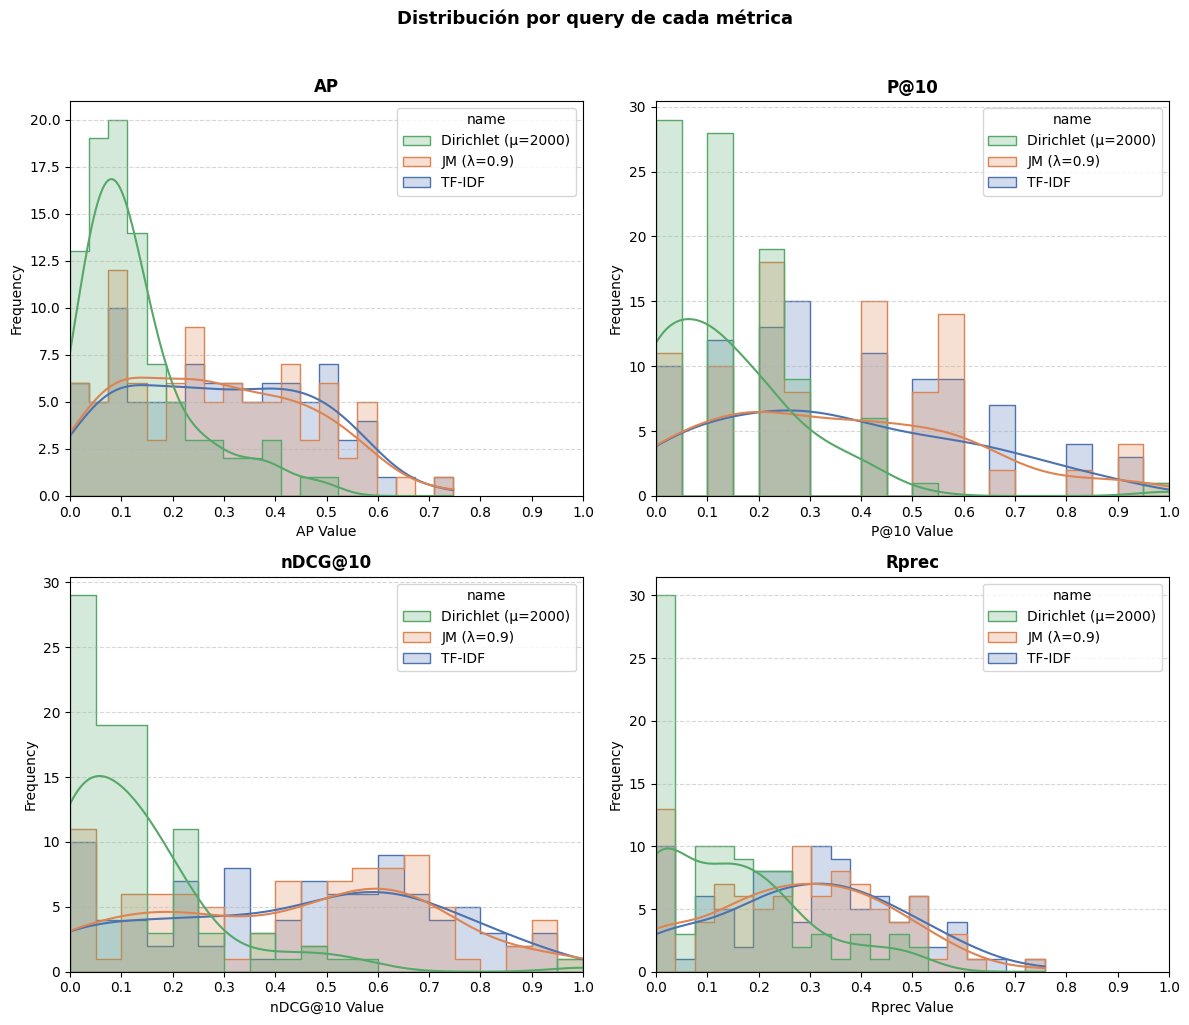

Guardado: distribucion_por_query.png


In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

metrics_to_plot = ["AP", "P@10", "nDCG@10", "Rprec"]
systems = ["TF-IDF", "JM (λ=0.9)", "Dirichlet (μ=2000)"]
colors  = ["#4C72B0", "#DD8452", "#55A868"]

# Cambiar a una cuadrícula de 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Distribución por query de cada métrica", fontsize=13, fontweight="bold", y=1.02) # Ajustar posición del título

# Define límites y marcas fijas para el eje x
fixed_limits = [0.0, 1.0]
fixed_ticks = np.arange(0.0, 1.1, 0.1)

# Crear un mapa de colores explícito para asegurar la asignación correcta
color_map = {system: color for system, color in zip(systems, colors)}

# Iterar sobre los ejes aplanados
for ax, metric in zip(axes.flatten(), metrics_to_plot):
    # Filtrar datos para la métrica actual
    metric_data = experiment_pq[experiment_pq["measure"] == metric].dropna(subset=["value"])

    # Trazar histograma para todos los sistemas, distinguidos por 'hue'
    sns.histplot(
        data=metric_data,
        x="value",
        hue="name",
        ax=ax,
        palette=color_map, # Usar el mapa de colores explícito
        element="step", # Usar líneas escalonadas para una mejor visibilidad de histogramas superpuestos
        kde=True, # Añadir estimación de densidad de kernel
        bins=20 # Número de "bins" para el histograma
    )

    ax.set_title(metric, fontweight="bold")
    ax.set_xlabel(f"{metric} Value")
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Aplicar límites y marcas fijas al eje x
    ax.set_xlim(fixed_limits)
    ax.set_xticks(fixed_ticks)

plt.tight_layout()
plt.savefig("distribucion_por_query.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: distribucion_por_query.png")

## 6. Curva Recall-Precision (11 puntos estándar)

In [33]:
from ir_measures import IPrec

# IPrec a los 11 niveles estándar de recall
recall_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
iprec_metrics = [IPrec(recall=r) for r in recall_levels]

rp_results = pt.Experiment(
    retr_systems=[tfidf, jm, dirichlet],
    topics=topics_eval[["qid", "query"]],
    qrels=qrels,
    eval_metrics=iprec_metrics,
    names=["TF-IDF", "JM (λ=0.9)", "Dirichlet (μ=2000)"]
)

rp_results

,name,IPrec@0.0,IPrec@0.1,IPrec@0.2,IPrec@0.3,IPrec@0.4,IPrec@0.5,IPrec@0.6,IPrec@0.7,IPrec@0.8,IPrec@0.9,IPrec@1.0
0,TF-IDF,0.724118,0.636186,0.521643,0.409678,0.337922,0.264870,0.195933,0.150978,0.103549,0.057312,0.024076
1,JM (λ=0.9),0.718696,0.614115,0.486113,0.391590,0.322327,0.258477,0.183486,0.138564,0.101288,0.059751,0.024331
2,Dirichlet (μ=2000),0.298245,0.241102,0.222111,0.195242,0.171069,0.143142,0.117247,0.093995,0.071934,0.045614,0.015007


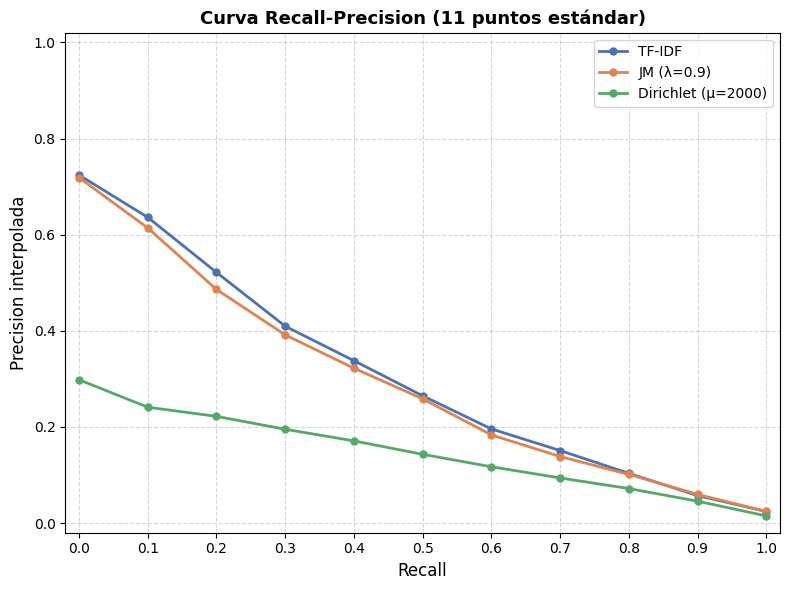

Guardado: curva_rp_11puntos.png


In [34]:
# Graficar curva R-P
col_names = [f"IPrec@{r:.1f}" for r in recall_levels]

fig, ax = plt.subplots(figsize=(8, 6))

for (_, row), color, label in zip(rp_results.iterrows(), colors, systems):
    precision_vals = [row[c] for c in col_names]
    ax.plot(recall_levels, precision_vals, marker="o", color=color,
            label=label, linewidth=2, markersize=5)

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision interpolada", fontsize=12)
ax.set_title("Curva Recall-Precision (11 puntos estándar)", fontsize=13, fontweight="bold")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_xticks(recall_levels)
ax.legend(fontsize=10)
ax.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("curva_rp_11puntos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: curva_rp_11puntos.png")

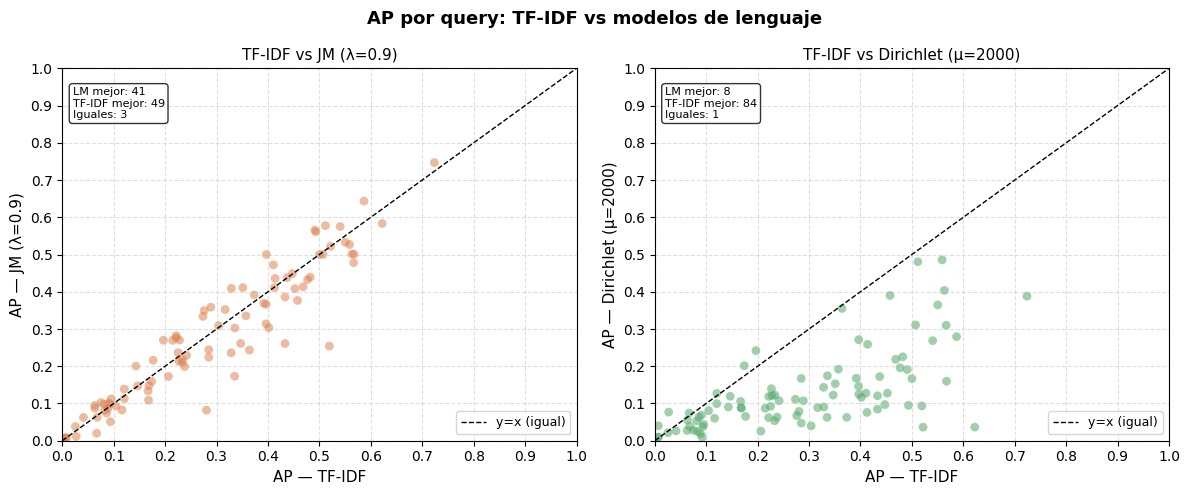

Guardado: scatter_ap_por_query.png


In [41]:
# Comparativa de modelos

# Scatter: MAP por query — TF-IDF vs JM y TF-IDF vs Dirichlet
pq_tfidf = experiment_pq[(experiment_pq["name"] == "TF-IDF") & (experiment_pq["measure"] == "AP")].set_index("qid")["value"]
pq_jm    = experiment_pq[(experiment_pq["name"] == "JM (λ=0.9)") & (experiment_pq["measure"] == "AP")].set_index("qid")["value"]
pq_dir   = experiment_pq[(experiment_pq["name"] == "Dirichlet (μ=2000)") & (experiment_pq["measure"] == "AP")].set_index("qid")["value"]

common = pq_tfidf.index.intersection(pq_jm.index).intersection(pq_dir.index)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("AP por query: TF-IDF vs modelos de lenguaje",
             fontsize=13, fontweight="bold")

# Define fixed limits and ticks for the axes
fixed_limits = [0.0, 1.0]
fixed_ticks = np.arange(0.0, 1.1, 0.1)

for ax, (pq_other, label, color) in zip(
    axes,
    [(pq_jm, "JM (λ=0.9)", colors[1]),
     (pq_dir, "Dirichlet (μ=2000)", colors[2])]
):
    x = pq_tfidf.loc[common].values
    y = pq_other.loc[common].values
    ax.scatter(x, y, alpha=0.55, color=color, edgecolors="none", s=40)
    ax.plot(fixed_limits, fixed_limits, "k--", linewidth=1, label="y=x (igual)")
    ax.set_xlabel("AP — TF-IDF", fontsize=11)
    ax.set_ylabel(f"AP — {label}", fontsize=11)
    ax.set_title(f"TF-IDF vs {label}", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(linestyle="--", alpha=0.4)

    # Set fixed x and y limits and ticks
    ax.set_xlim(fixed_limits)
    ax.set_ylim(fixed_limits)
    ax.set_xticks(fixed_ticks)
    ax.set_yticks(fixed_ticks)

    n_better  = (y > x).sum()
    n_worse   = (y < x).sum()
    n_equal   = (y == x).sum()
    ax.text(0.02, 0.95,
            f"LM mejor: {n_better}\nTF-IDF mejor: {n_worse}\nIguales: {n_equal}",
            transform=ax.transAxes, fontsize=8,
            va="top", bbox=dict(boxstyle="round", fc="white", alpha=0.8))

plt.tight_layout()
plt.savefig("scatter_ap_por_query.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: scatter_ap_por_query.png")